In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


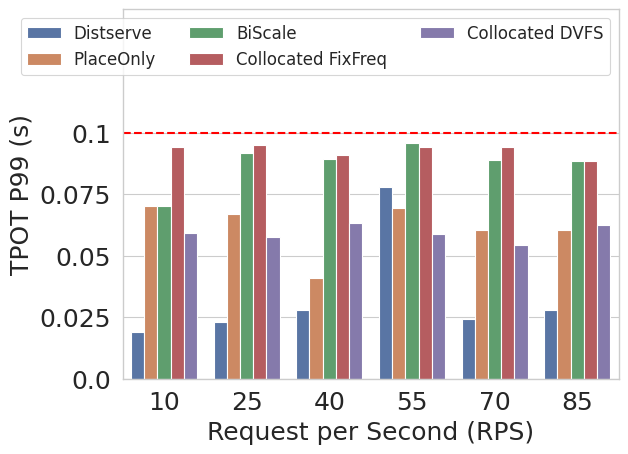

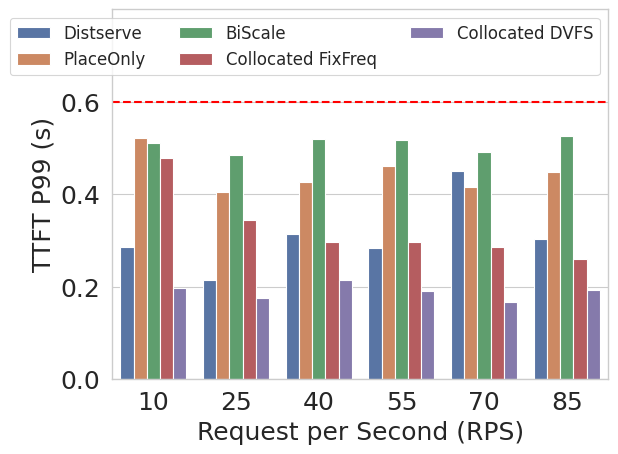

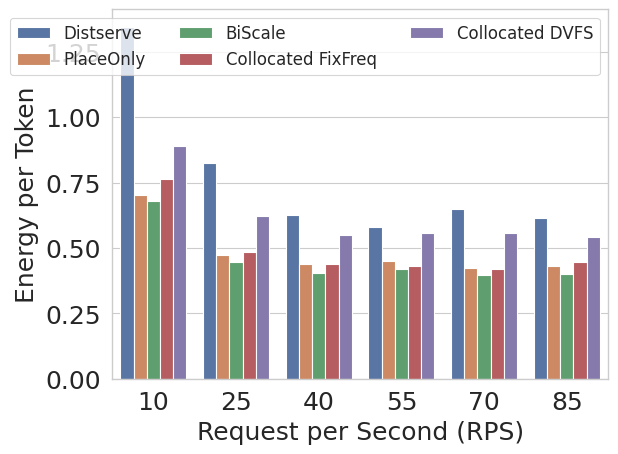

In [54]:
path = "/export2/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/synthetic_char_balance/metrics.csv"
df_results_disag = pd.read_csv(path)
df_results_disag = df_results_disag[~df_results_disag['expr_dir'].isin([
    'OURS_R5_JAN3_B5_6_DVFS', 'OURS_R5_JAN3_B5_5_DVFS',
    'OURS_R5_JAN3_B5_4_DVFS', 'OURS_R5_JAN3_B5_3_DVFS',
    'OURS_R5_JAN3_B5_2_DVFS', 'OURS_R5_JAN3_B5_1_DVFS'
])]

path = '/export2/obasit/ClusterLevelServing/vllm_logs/asplos_logs/collocated_logs/ours/DVFS/synthetic/profiler_logs_Feb28_chunk_dvfs_b5_0/metrics.csv'
df_results_collocated_dvfs = pd.read_csv(path)

path = '/export2/obasit/ClusterLevelServing/vllm_logs/asplos_logs/collocated_logs/ours/profiler_logs_Feb25_chunk_fix_freq_0/synthetic/metrics.csv'
df_results_collocated_fix_freq = pd.read_csv(path)

df_results = pd.concat([df_results_disag, df_results_collocated_dvfs, df_results_collocated_fix_freq])

# Create a mapping for renaming expr_dir values
rename_mapping = {
    'DISTSERVE_R5_JAN3_B5_1': 'Distserve 85',
    'DISTSERVE_R5_JAN3_B5_2': 'Distserve 70',
    'DISTSERVE_R5_JAN3_B5_3': 'Distserve 55',
    'DISTSERVE_R5_JAN3_B5_4': 'Distserve 40',
    'DISTSERVE_R5_JAN3_B5_5': 'Distserve 25',
    'DISTSERVE_R5_JAN3_B5_6': 'Distserve 10',
    'OURS_R5_JAN3_B5_1': 'PlaceOnly 85',
    'OURS_R5_JAN3_B5_2': 'PlaceOnly 70',
    'OURS_R5_JAN3_B5_3': 'PlaceOnly 55',
    'OURS_R5_JAN3_B5_4': 'PlaceOnly 40',
    'OURS_R5_JAN3_B5_5': 'PlaceOnly 25',
    'OURS_R5_JAN3_B5_6': 'PlaceOnly 10',
    'OURS_R5_JAN3_B5_1_DVFS_W': 'BiScale 85',
    'OURS_R5_JAN3_B5_2_DVFS_W': 'BiScale 70',
    'OURS_R5_JAN3_B5_3_DVFS_W': 'BiScale 55',
    'OURS_R5_JAN3_B5_4_DVFS_W': 'BiScale 40',
    'OURS_R5_JAN3_B5_5_DVFS_W': 'BiScale 25',
    'OURS_R5_JAN3_B5_6_DVFS_W': 'BiScale 10',
    'OURS_CHUNK_FEB24_B5_1_DVFS_node0': 'Collocated DVFS 85',
    'OURS_CHUNK_FEB24_B5_2_DVFS_node0': 'Collocated DVFS 70',
    'OURS_CHUNK_FEB24_B5_3_DVFS_node0': 'Collocated DVFS 55',
    'OURS_CHUNK_FEB24_B5_4_DVFS_node0': 'Collocated DVFS 40',
    'OURS_CHUNK_FEB24_B5_5_DVFS_node0': 'Collocated DVFS 25',
    'OURS_CHUNK_FEB24_B5_6_DVFS_node0': 'Collocated DVFS 10',
    'OURS_CHUNK_FEB24_B5_1_node0': 'Collocated FixFreq 85',
    'OURS_CHUNK_FEB24_B5_2_node0': 'Collocated FixFreq 70',
    'OURS_CHUNK_FEB24_B5_3_node0': 'Collocated FixFreq 55',
    'OURS_CHUNK_FEB24_B5_4_node0': 'Collocated FixFreq 40',
    'OURS_CHUNK_FEB24_B5_5_node0': 'Collocated FixFreq 25',
    'OURS_CHUNK_FEB24_B5_6_node0': 'Collocated FixFreq 10'

}

# Replace values in expr_dir column
df_results['expr_dir'] = df_results['expr_dir'].replace(rename_mapping)

df_results = df_results[df_results["instance"] == "total"]

# Sort the dataframe by extracting the numeric suffix from expr_dir
df_results['sort_key'] = df_results['expr_dir'].str.extract('(\d+)$')[0].fillna(0).astype(int)
df_results = df_results.sort_values('sort_key')

# Extract RPS and name from expr_dir
df_results['rps'] = df_results['expr_dir'].str.extract('(\d+)$')[0].astype(int)
df_results['name'] = df_results['expr_dir'].str.replace('\s+\d+$', '', regex=True)
# Set the order of the categories
df_results['name'] = pd.Categorical(df_results['name'], categories=['Distserve', 'PlaceOnly', 'BiScale', 'Collocated FixFreq', 'Collocated DVFS'], ordered=True)
df_results = df_results.sort_values(['rps', 'name'])

#################### TPOT P99 ####################

sns.set_theme(context="paper", style="whitegrid")
plt.figure()
ax = sns.barplot(
    x="rps", 
    y="tpot_p99", 
    hue="name", 
    data=df_results, 
    dodge=True
)
ax.axhline(y=0.1, color='red', linestyle='--', linewidth=1.5)

# Customize the plot
ax.set_xlabel('Request per Second (RPS)', fontsize=18)
ax.set_ylabel('TPOT P99 (s)', fontsize=18)
ax.set_ylim(0, 0.15)
ax.set_xticks([0, 1, 2, 3, 4, 5])
# ax.set_xlim([0.5, 6.5])
ax.set_xticklabels(['10', '25', '40', '55', '70', '85'], fontsize=18)
ax.set_yticks([0.0, 0.025, 0.05, 0.075, 0.1])
ax.set_yticklabels(['0.0', '0.025', '0.05', '0.075', '0.1'], fontsize=18)
ax.legend_.set_title('')
ax.legend(fontsize=12, ncol=3)
plt.savefig("figs/sythetic_trace_tpot.pdf", format="pdf")

#################### TTFT P99 ####################

sns.set_theme(context="paper", style="whitegrid")
plt.figure()
ax = sns.barplot(
    x="rps", 
    y="ttft_p99", 
    hue="name", 
    data=df_results, 
    dodge=True
)
ax.axhline(y=0.6, color='red', linestyle='--', linewidth=1.5)

# Customize the plot
ax.set_xlabel('Request per Second (RPS)', fontsize=18)
ax.set_ylabel('TTFT P99 (s)', fontsize=18)
ax.set_ylim(0, 0.8)
ax.set_xticks([0, 1, 2, 3, 4, 5])
# ax.set_xlim([0.5, 6.5])
ax.set_xticklabels(['10', '25', '40', '55', '70', '85'], fontsize=18)
ax.set_yticks([0.0, 0.2, 0.4, 0.6])
ax.set_yticklabels(['0.0', '0.2', '0.4', '0.6'], fontsize=18)
ax.legend_.set_title('')
ax.legend(fontsize=12, ncol=3)
plt.savefig("figs/sythetic_trace_ttft.pdf", format="pdf")

#################### Energy per token ####################

sns.set_theme(context="paper", style="whitegrid")
plt.figure()
ax = sns.barplot(
    x="rps", 
    y="energy_per_token", 
    hue="name", 
    data=df_results, 
    dodge=True
)

# Customize the plot
ax.set_xlabel('Request per Second (RPS)', fontsize=18)
ax.set_ylabel('Energy per Token', fontsize=18)
ax.set_xticks([0, 1, 2, 3, 4, 5])
# ax.set_xlim([0.5, 6.5])
ax.set_xticklabels(['10', '25', '40', '55', '70', '85'], fontsize=18)
ax.tick_params(axis='y', labelsize=18)
ax.legend_.set_title('')
ax.legend(fontsize=12, ncol=3)
plt.savefig("figs/sythetic_trace_energy_per_token.pdf", format="pdf")

/tmp/ipykernel_1774882/4290699443.py:94: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_1774882/4290699443.py:120: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_1774882/4290699443.py:143: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


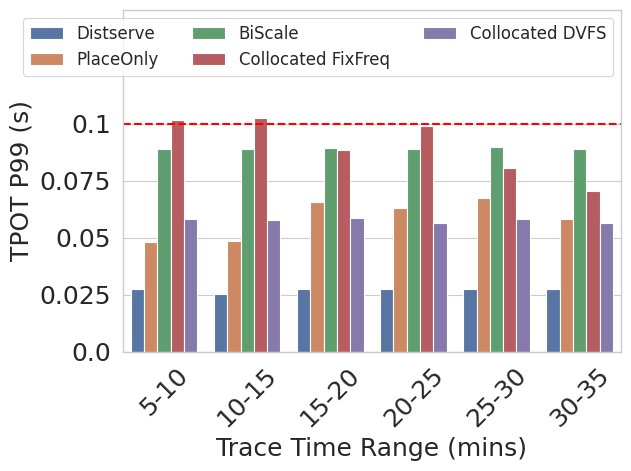

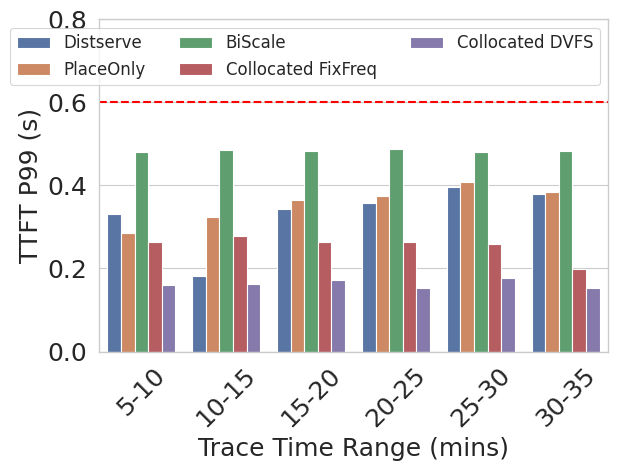

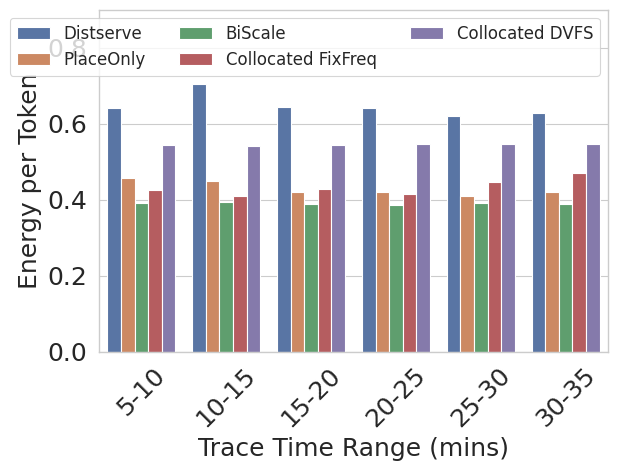

In [59]:
path = "/export2/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/67_percent_char_balance/metrics.csv"
df_results_disag = pd.read_csv(path)
df_results_disag = df_results_disag[~df_results_disag['expr_dir'].isin([
    'OURS_R5_JAN3_OLD_P90_6_DVFS', 'OURS_R5_JAN3_OLD_P90_5_DVFS',
    'OURS_R5_JAN3_OLD_P90_4_DVFS', 'OURS_R5_JAN3_OLD_P90_3_DVFS',
    'OURS_R5_JAN3_OLD_P90_2_DVFS', 'OURS_R5_JAN3_OLD_P90_1_DVFS'
])]

path = '/export2/obasit/ClusterLevelServing/vllm_logs/asplos_logs/collocated_logs/ours/DVFS/real/profiler_logs_Feb28_chunk_dvfs_other_0/metrics.csv'
df_results_collocated_dvfs = pd.read_csv(path)

path = '/export2/obasit/ClusterLevelServing/vllm_logs/asplos_logs/collocated_logs/ours/profiler_logs_Feb25_chunk_fix_freq_0/real/metrics.csv'
df_results_collocated_fix_freq = pd.read_csv(path)

df_results = pd.concat([df_results_disag, df_results_collocated_dvfs, df_results_collocated_fix_freq])

# Create a mapping for renaming expr_dir values
rename_mapping = {
    'DISTSERVE_R5_JAN3_OLD_P90_6': 'Distserve 85',
    'DISTSERVE_R5_JAN3_OLD_P90_5': 'Distserve 70',
    'DISTSERVE_R5_JAN3_OLD_P90_4': 'Distserve 55',
    'DISTSERVE_R5_JAN3_OLD_P90_3': 'Distserve 40',
    'DISTSERVE_R5_JAN3_OLD_P90_2': 'Distserve 25',
    'DISTSERVE_R5_JAN3_OLD_P90_1': 'Distserve 10',
    'OURS_R5_JAN3_OLD_P90_6': 'PlaceOnly 85',
    'OURS_R5_JAN3_OLD_P90_5': 'PlaceOnly 70',
    'OURS_R5_JAN3_OLD_P90_4': 'PlaceOnly 55',
    'OURS_R5_JAN3_OLD_P90_3': 'PlaceOnly 40',
    'OURS_R5_JAN3_OLD_P90_2': 'PlaceOnly 25',
    'OURS_R5_JAN3_OLD_P90_1': 'PlaceOnly 10',
    'OURS_R5_JAN3_OLD_P90_1_DVFS_W': 'BiScale 10',
    'OURS_R5_JAN3_OLD_P90_2_DVFS_W': 'BiScale 25',
    'OURS_R5_JAN3_OLD_P90_3_DVFS_W': 'BiScale 40',
    'OURS_R5_JAN3_OLD_P90_4_DVFS_W': 'BiScale 55',
    'OURS_R5_JAN3_OLD_P90_5_DVFS_W': 'BiScale 70',
    'OURS_R5_JAN3_OLD_P90_6_DVFS_W': 'BiScale 85',
    'OURS_CHUNK_FEB24_REAL_P67_1_node0': 'Collocated FixFreq 85',
    'OURS_CHUNK_FEB24_REAL_P67_2_node0': 'Collocated FixFreq 70',
    'OURS_CHUNK_FEB24_REAL_P67_3_node0': 'Collocated FixFreq 55',
    'OURS_CHUNK_FEB24_REAL_P67_4_node0': 'Collocated FixFreq 40',
    'OURS_CHUNK_FEB24_REAL_P67_5_node0': 'Collocated FixFreq 25',
    'OURS_CHUNK_FEB24_REAL_P67_6_node0': 'Collocated FixFreq 10',
    'OURS_CHUNK_FEB24_REAL_P67_1_DVFS_node1': 'Collocated DVFS 85',
    'OURS_CHUNK_FEB24_REAL_P67_2_DVFS_node1': 'Collocated DVFS 70',
    'OURS_CHUNK_FEB24_REAL_P67_3_DVFS_node1': 'Collocated DVFS 55',
    'OURS_CHUNK_FEB24_REAL_P67_4_DVFS_node1': 'Collocated DVFS 40',
    'OURS_CHUNK_FEB24_REAL_P67_5_DVFS_node1': 'Collocated DVFS 25',
    'OURS_CHUNK_FEB24_REAL_P67_6_DVFS_node1': 'Collocated DVFS 10'

}


# Replace values in expr_dir column
df_results['expr_dir'] = df_results['expr_dir'].replace(rename_mapping)
df_results = df_results[df_results['expr_dir'].isin(rename_mapping.values())]
df_results = df_results[~df_results['expr_dir'].str.contains('OURS_R5_JAN3_OLD_P90_.*_DVFS', regex=True)]

df_results = df_results[df_results["instance"] == "total"]

# Sort the dataframe by extracting the numeric suffix from expr_dir
df_results['sort_key'] = df_results['expr_dir'].str.extract('(\d+)$')[0].fillna(0).astype(int)
df_results = df_results.sort_values('sort_key')

# Extract RPS and name from expr_dir
df_results['rps'] = df_results['expr_dir'].str.extract('(\d+)$')[0].astype(int)
df_results['name'] = df_results['expr_dir'].str.replace('\s+\d+$', '', regex=True)
# Set the order of the categories
df_results['name'] = pd.Categorical(df_results['name'], categories=['Distserve', 'PlaceOnly', 'BiScale', 'Collocated FixFreq', 'Collocated DVFS'], ordered=True)
df_results = df_results.sort_values(['rps', 'name'])

####################### TPOT P99 #######################

sns.set_theme(context="paper", style="whitegrid")
plt.figure(constrained_layout=True)
ax = sns.barplot(
    x="rps", 
    y="tpot_p99", 
    hue="name", 
    data=df_results, 
    dodge=True
)
ax.axhline(y=0.1, color='red', linestyle='--', linewidth=1.5)
# Customize the plot
ax.set_xlabel('Trace Time Range (mins)', fontsize=18)
ax.set_ylabel('TPOT P99 (s)', fontsize=18)
ax.set_ylim(0, 0.15)
ax.legend(title='', fontsize=18)
ax.set_xticks([0,1,2, 3, 4, 5])
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=18, rotation=45, ha='center')
ax.set_yticks([0.0, 0.025, 0.05, 0.075, 0.1])
ax.set_yticklabels(['0.0', '0.025', '0.05', '0.075', '0.1'], fontsize=18)
ax.legend(fontsize=12, ncol=3)

plt.tight_layout()
plt.savefig("figs/real_67p_trace_tpot.pdf", format="pdf")

######################## TTFT P99 #######################

sns.set_theme(context="paper", style="whitegrid")
plt.figure(constrained_layout=True)
ax = sns.barplot(
    x="rps", 
    y="ttft_p99", 
    hue="name", 
    data=df_results, 
    dodge=True
)
ax.axhline(y=0.6, color='red', linestyle='--', linewidth=1.5)
# Customize the plot
ax.set_xlabel('Trace Time Range (mins)', fontsize=18)
ax.set_ylabel('TTFT P99 (s)', fontsize=18)
ax.set_ylim(0, 0.8)
ax.legend(title='', fontsize=18)
ax.set_xticks([0,1,2, 3, 4, 5])
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=18, rotation=45, ha='center')
ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8])
ax.set_yticklabels(['0.0', '0.2', '0.4', '0.6', '0.8'], fontsize=18)
ax.legend(fontsize=12, ncol=3)

plt.tight_layout()
plt.savefig("figs/real_67p_trace_ttft.pdf", format="pdf")

############################ energy per token #######################
sns.set_theme(context="paper", style="whitegrid")
plt.figure(constrained_layout=True)
ax = sns.barplot(
    x="rps", 
    y="energy_per_token", 
    hue="name", 
    data=df_results, 
    dodge=True
)
# Customize the plot
ax.set_xlabel('Trace Time Range (mins)', fontsize=18)
ax.set_ylabel('Energy per Token', fontsize=18)
ax.set_ylim(0, 0.9)

ax.set_xticks([0,1,2, 3, 4, 5])
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=18, rotation=45, ha='center')
ax.tick_params(axis='y', labelsize=18)
ax.legend(fontsize=12, ncol=3)

plt.tight_layout()
plt.savefig("figs/real_67p_trace_energy_per_token.pdf", format="pdf")


/tmp/ipykernel_1774882/635017397.py:94: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_1774882/635017397.py:120: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_1774882/635017397.py:142: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


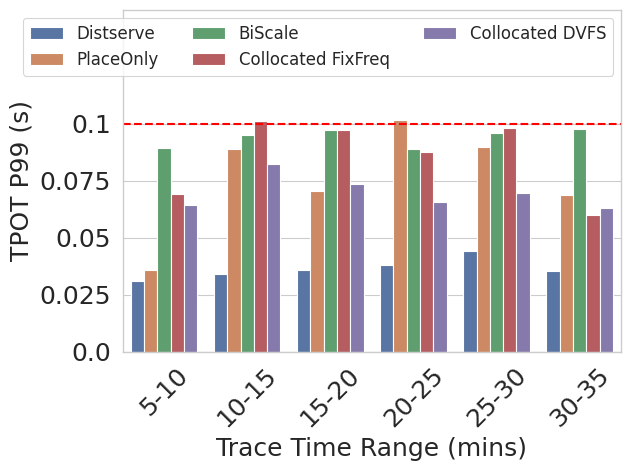

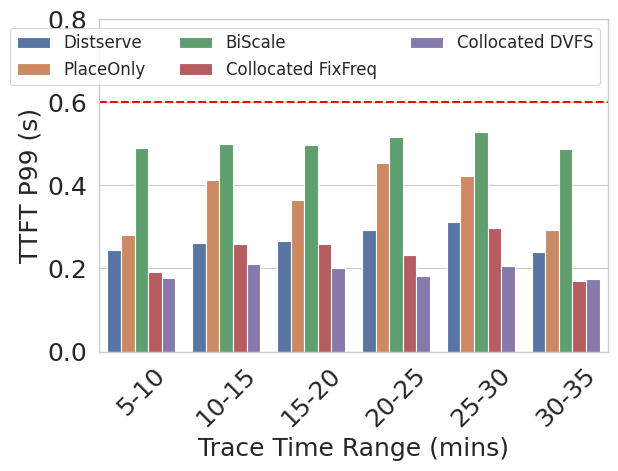

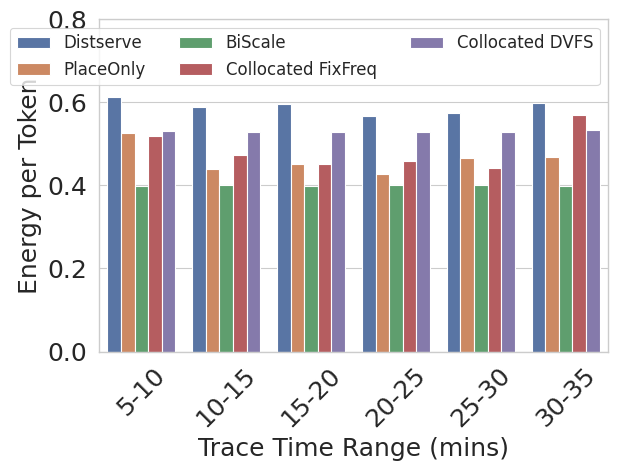

In [57]:
path = "/export2/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/85_percent_char_balance/metrics.csv"
df_results_disag = pd.read_csv(path)
df_results_disag = df_results_disag[~df_results_disag['expr_dir'].isin([
    'OURS_R5_JAN3_REAL_P85_6_DVFS', 'OURS_R5_JAN3_REAL_P85_5_DVFS',
    'OURS_R5_JAN3_REAL_P85_4_DVFS', 'OURS_R5_JAN3_REAL_P85_3_DVFS',
    'OURS_R5_JAN3_REAL_P85_2_DVFS', 'OURS_R5_JAN3_REAL_P85_1_DVFS'
])]

path = '/export2/obasit/ClusterLevelServing/vllm_logs/asplos_logs/collocated_logs/ours/DVFS/real/profiler_logs_Feb28_chunk_dvfs_other_0/metrics.csv'
df_results_collocated_dvfs = pd.read_csv(path)

path = '/export2/obasit/ClusterLevelServing/vllm_logs/asplos_logs/collocated_logs/ours/profiler_logs_Feb25_chunk_fix_freq_0/real/metrics.csv'
df_results_collocated_fix_freq = pd.read_csv(path)

df_results = pd.concat([df_results_disag, df_results_collocated_dvfs, df_results_collocated_fix_freq])

# Create a mapping for renaming expr_dir values
rename_mapping = {
    'DISTSERVE_R5_JAN3_REAL_P85_6': 'Distserve 85',
    'DISTSERVE_R5_JAN3_REAL_P85_5': 'Distserve 70',
    'DISTSERVE_R5_JAN3_REAL_P85_4': 'Distserve 55',
    'DISTSERVE_R5_JAN3_REAL_P85_3': 'Distserve 40',
    'DISTSERVE_R5_JAN3_REAL_P85_2': 'Distserve 25',
    'DISTSERVE_R5_JAN3_REAL_P85_1': 'Distserve 10',
    'OURS_R5_JAN3_REAL_P85_6': 'PlaceOnly 85',
    'OURS_R5_JAN3_REAL_P85_5': 'PlaceOnly 70',
    'OURS_R5_JAN3_REAL_P85_4': 'PlaceOnly 55',
    'OURS_R5_JAN3_REAL_P85_3': 'PlaceOnly 40',
    'OURS_R5_JAN3_REAL_P85_2': 'PlaceOnly 25',
    'OURS_R5_JAN3_REAL_P85_1': 'PlaceOnly 10',
    'OURS_R5_JAN3_REAL_P85_6_DVFS_W': 'BiScale 85',
    'OURS_R5_JAN3_REAL_P85_5_DVFS_W': 'BiScale 70',
    'OURS_R5_JAN3_REAL_P85_4_DVFS_W': 'BiScale 55',
    'OURS_R5_JAN3_REAL_P85_3_DVFS_W': 'BiScale 40',
    'OURS_R5_JAN3_REAL_P85_2_DVFS_W': 'BiScale 25',
    'OURS_R5_JAN3_REAL_P85_1_DVFS_W': 'BiScale 10',
    'OURS_CHUNK_FEB24_REAL_P85_1_node0': 'Collocated FixFreq 85',
    'OURS_CHUNK_FEB24_REAL_P85_2_node0': 'Collocated FixFreq 70',
    'OURS_CHUNK_FEB24_REAL_P85_3_node0': 'Collocated FixFreq 55',
    'OURS_CHUNK_FEB24_REAL_P85_4_node0': 'Collocated FixFreq 40',
    'OURS_CHUNK_FEB24_REAL_P85_5_node0': 'Collocated FixFreq 25',
    'OURS_CHUNK_FEB24_REAL_P85_6_node0': 'Collocated FixFreq 10',
    'OURS_CHUNK_FEB24_REAL_P85_1_DVFS_node1': 'Collocated DVFS 85',
    'OURS_CHUNK_FEB24_REAL_P85_2_DVFS_node1': 'Collocated DVFS 70',
    'OURS_CHUNK_FEB24_REAL_P85_3_DVFS_node1': 'Collocated DVFS 55',
    'OURS_CHUNK_FEB24_REAL_P85_4_DVFS_node1': 'Collocated DVFS 40',
    'OURS_CHUNK_FEB24_REAL_P85_5_DVFS_node1': 'Collocated DVFS 25',
    'OURS_CHUNK_FEB24_REAL_P85_6_DVFS_node1': 'Collocated DVFS 10'

}


# Replace values in expr_dir column
df_results['expr_dir'] = df_results['expr_dir'].replace(rename_mapping)
df_results = df_results[df_results['expr_dir'].isin(rename_mapping.values())]
df_results = df_results[~df_results['expr_dir'].str.contains('OURS_R5_JAN3_OLD_P90_.*_DVFS', regex=True)]

df_results = df_results[df_results["instance"] == "total"]

# Sort the dataframe by extracting the numeric suffix from expr_dir
df_results['sort_key'] = df_results['expr_dir'].str.extract('(\d+)$')[0].fillna(0).astype(int)
df_results = df_results.sort_values('sort_key')

# Extract RPS and name from expr_dir
df_results['rps'] = df_results['expr_dir'].str.extract('(\d+)$')[0].astype(int)
df_results['name'] = df_results['expr_dir'].str.replace('\s+\d+$', '', regex=True)
# Set the order of the categories
df_results['name'] = pd.Categorical(df_results['name'], categories=['Distserve', 'PlaceOnly', 'BiScale', 'Collocated FixFreq', 'Collocated DVFS'], ordered=True)
df_results = df_results.sort_values(['rps', 'name'])

####################### TPOT P99 #######################

sns.set_theme(context="paper", style="whitegrid")
plt.figure(constrained_layout=True)
ax = sns.barplot(
    x="rps", 
    y="tpot_p99", 
    hue="name", 
    data=df_results, 
    dodge=True
)
ax.axhline(y=0.1, color='red', linestyle='--', linewidth=1.5)
# Customize the plot
ax.set_xlabel('Trace Time Range (mins)', fontsize=18)
ax.set_ylabel('TPOT P99 (s)', fontsize=18)
ax.set_ylim(0, 0.15)
ax.legend(title='', fontsize=18)
ax.set_xticks([0,1,2, 3, 4, 5])
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=18, rotation=45, ha='center')
ax.set_yticks([0.0, 0.025, 0.05, 0.075, 0.1])
ax.set_yticklabels(['0.0', '0.025', '0.05', '0.075', '0.1'], fontsize=18)
ax.legend(fontsize=12, ncol=3)

plt.tight_layout()
plt.savefig("figs/real_85p_trace_tpot.pdf", format="pdf")

######################## TTFT P99 #######################

sns.set_theme(context="paper", style="whitegrid")
plt.figure(constrained_layout=True)
ax = sns.barplot(
    x="rps", 
    y="ttft_p99", 
    hue="name", 
    data=df_results, 
    dodge=True
)
ax.axhline(y=0.6, color='red', linestyle='--', linewidth=1.5)
# Customize the plot
ax.set_xlabel('Trace Time Range (mins)', fontsize=18)
ax.set_ylabel('TTFT P99 (s)', fontsize=18)
ax.set_ylim(0, 0.8)
ax.legend(title='', fontsize=18)
ax.set_xticks([0,1,2, 3, 4, 5])
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=18, rotation=45, ha='center')
ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8])
ax.set_yticklabels(['0.0', '0.2', '0.4', '0.6', '0.8'], fontsize=18)
ax.legend(fontsize=12, ncol=3)

plt.tight_layout()
plt.savefig("figs/real_85p_trace_ttft.pdf", format="pdf")

############################ energy per token #######################
sns.set_theme(context="paper", style="whitegrid")
plt.figure(constrained_layout=True)
ax = sns.barplot(
    x="rps", 
    y="energy_per_token", 
    hue="name", 
    data=df_results, 
    dodge=True
)
# Customize the plot
ax.set_xlabel('Trace Time Range (mins)', fontsize=18)
ax.set_ylabel('Energy per Token', fontsize=18)
ax.set_ylim(0, 0.8)
ax.set_xticks([0,1,2, 3, 4, 5])
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=18, rotation=45, ha='center')
ax.tick_params(axis='y', labelsize=18)
ax.legend(fontsize=12, ncol=3)

plt.tight_layout()
plt.savefig("figs/real_85p_trace_energy_per_token.pdf", format="pdf")
